Loading model... (This may take a few seconds)
Model loaded successfully!


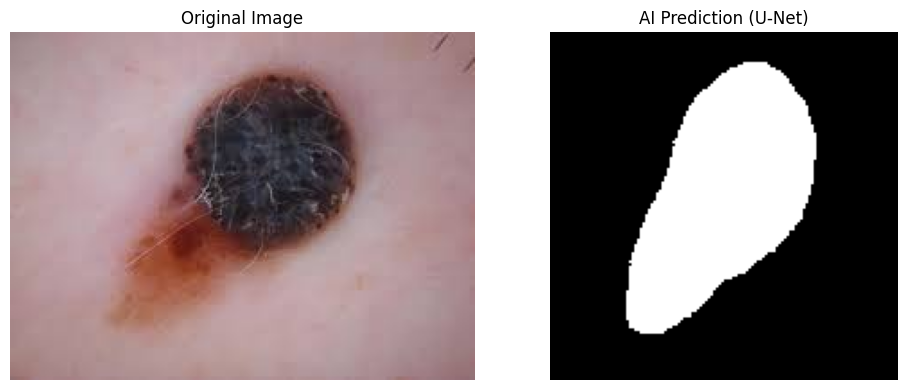

In [2]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- SETTINGS ---
MODEL_PATH = 'unet_skin_lesion_model.keras'
IMG_HEIGHT = 128
IMG_WIDTH = 128

# 1. Load the trained model
if not os.path.exists(MODEL_PATH):
    print(f"Error: Model file '{MODEL_PATH}' not found!")
    print("Please download it from Kaggle Output first.")
    exit()

print("Loading model... (This may take a few seconds)")
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded successfully!")

def predict_local_image(image_path):
    # 2. Load and Preprocess the Image
    if not os.path.exists(image_path):
        print(f"Error: Image '{image_path}' not found.")
        return

    original_img = cv2.imread(image_path)
    if original_img is None:
        print("Error: Could not read image.")
        return

    # Convert to RGB (OpenCV loads as BGR)
    input_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    
    # Resize to match model input
    resized_img = cv2.resize(input_img, (IMG_WIDTH, IMG_HEIGHT))
    
    # Normalize (0-1) and Expand Dims (Batch of 1)
    # Shape becomes (1, 128, 128, 3)
    img_array = np.expand_dims(resized_img / 255.0, axis=0)

    # 3. Predict
    pred_prob = model.predict(img_array, verbose=0)[0]
    
    # Threshold (Binary Mask)
    pred_mask = (pred_prob > 0.5).astype(np.float32)

    # 4. Visualization
    plt.figure(figsize=(10, 4))

    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(input_img)
    plt.title("Original Image")
    plt.axis('off')

    # Predicted Mask
    plt.subplot(1, 2, 2)
    plt.imshow(pred_mask, cmap='gray')
    plt.title("AI Prediction (U-Net)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- RUN THE DEMO ---
# Replace 'test_image.jpg' with any image filename you have locally
image_filename = input("Enter the image filename (e.g., photo.jpg): ")
predict_local_image(image_filename)